# Softmax exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

This exercise is analogous to the SVM exercise. You will:

- implement a fully-vectorized **loss function** for the Softmax classifier
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** with numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [1]:
import os
import sys
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Change to the 'assignment_one' directory and add it to the Python path
# This assumes 'assignment_one' is directly under MyDrive. Adjust path if necessary.
assignment_one_path = '/content/drive/MyDrive/assignment1'
os.chdir(assignment_one_path)

# Add the current directory to sys.path to ensure modules like cs231n can be found
if assignment_one_path not in sys.path:
    sys.path.insert(0, assignment_one_path)

# Import necessary functions, which were previously causing ModuleNotFoundError
from cs231n.data_utils import load_CIFAR10
from cs231n.classifiers import KNearestNeighbor

print(f"Current working directory changed to: {os.getcwd()}")

Mounted at /content/drive
Current working directory changed to: /content/drive/MyDrive/assignment1


In [2]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [3]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]

    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image

    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Softmax Classifier

Your code for this section will all be written inside **cs231n/classifiers/softmax.py**.


In [4]:
# First implement the naive softmax loss function with nested loops.
# Open the file cs231n/classifiers/softmax.py and implement the
# softmax_loss_naive function.

from cs231n.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.341944
sanity check: 2.302585


## Inline Question 1:
Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

**Your answer:** *0.1 - probability of 1/10 classes*


In [5]:
# Complete the implementation of softmax_loss_naive and implement a (naive)
# version of the gradient that uses nested loops.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As we did for the SVM, use numeric gradient checking as a debugging tool.
# The numeric gradient should be close to the analytic gradient.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

# similar to SVM case, do another gradient check with regularization
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 0.362752 analytic: 0.362752, relative error: 3.832064e-08
numerical: -0.571040 analytic: -0.571040, relative error: 6.860142e-08
numerical: 1.769592 analytic: 1.769592, relative error: 9.481458e-09
numerical: 2.510572 analytic: 2.510572, relative error: 2.168690e-08
numerical: -1.444653 analytic: -1.444653, relative error: 3.896775e-08
numerical: 2.405401 analytic: 2.405401, relative error: 1.652670e-08
numerical: -1.793274 analytic: -1.793274, relative error: 1.614026e-08
numerical: 1.900553 analytic: 1.900553, relative error: 5.837825e-08
numerical: 1.476271 analytic: 1.476271, relative error: 6.354178e-08
numerical: 0.204404 analytic: 0.204404, relative error: 6.019684e-08
numerical: 3.983881 analytic: 3.983881, relative error: 2.046944e-08
numerical: -0.636286 analytic: -0.636285, relative error: 8.684381e-08
numerical: 1.008428 analytic: 1.008427, relative error: 8.015426e-08
numerical: 0.184732 analytic: 0.184732, relative error: 2.350080e-07
numerical: -3.374763 analy

In [6]:
# Now that we have a naive implementation of the softmax loss function and its gradient,
# implement a vectorized version in softmax_loss_vectorized.
# The two versions should compute the same results, but the vectorized version should be
# much faster.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# As we did for the SVM, we use the Frobenius norm to compare the two versions
# of the gradient.
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.341944e+00 computed in 0.277525s
vectorized loss: 2.341944e+00 computed in 0.063672s
Loss difference: 0.000000
Gradient difference: 0.000000


In [7]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of over 0.35 on the validation set.
from cs231n.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None
learning_rates = [8e-8, 9e-8, 1e-7, 2e-7]
regularization_strengths = [8e3, 10e3, 12e3, 15e3]

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained softmax classifer in best_softmax.                          #
################################################################################
import itertools
lr_reg_pairs = list(itertools.product(learning_rates, regularization_strengths))
num_of_iters = len(lr_reg_pairs)

for i, (lr, reg) in enumerate(lr_reg_pairs):
    print('Calculating the model #{}/{} with:'.format(i+1, num_of_iters))
    print('    - learning rate {}'.format(lr))
    print('    - regularization strength {}'.format(reg))

    softmax = Softmax()
    softmax.train(X_train, y_train,
              learning_rate=lr, reg=reg,
              num_iters=1500, verbose=False)

    y_train_pred = softmax.predict(X_train)
    training_accuracy = np.mean(y_train == y_train_pred)
    y_val_pred = softmax.predict(X_val)
    valid_accuracy = np.mean(y_val == y_val_pred)

    if valid_accuracy > best_val:
        best_val = valid_accuracy
        best_softmax = softmax
    results[(lr, reg)] = (training_accuracy, valid_accuracy)

    print('Model #{} accuracy: {:.4f}'.format(i+1, valid_accuracy))
    print('Best model accuracy: {:.4f}\n'.format(best_val))
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

Calculating the model #1/16 with:
    - learning rate 8e-08
    - regularization strength 8000.0
Model #1 accuracy: 0.3430
Best model accuracy: 0.3430

Calculating the model #2/16 with:
    - learning rate 8e-08
    - regularization strength 10000.0
Model #2 accuracy: 0.3600
Best model accuracy: 0.3600

Calculating the model #3/16 with:
    - learning rate 8e-08
    - regularization strength 12000.0
Model #3 accuracy: 0.3700
Best model accuracy: 0.3700

Calculating the model #4/16 with:
    - learning rate 8e-08
    - regularization strength 15000.0
Model #4 accuracy: 0.3570
Best model accuracy: 0.3700

Calculating the model #5/16 with:
    - learning rate 9e-08
    - regularization strength 8000.0
Model #5 accuracy: 0.3570
Best model accuracy: 0.3700

Calculating the model #6/16 with:
    - learning rate 9e-08
    - regularization strength 10000.0
Model #6 accuracy: 0.3570
Best model accuracy: 0.3700

Calculating the model #7/16 with:
    - learning rate 9e-08
    - regularization str

In [8]:
# evaluate on test set
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.369000


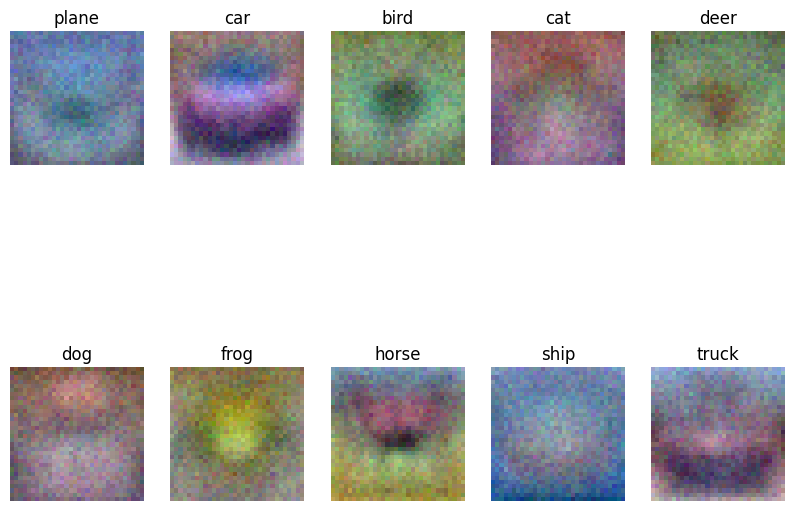

In [9]:
# Visualize the learned weights for each class
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])